In [99]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 



In [100]:
df = pd.read_csv('Static Data 2')

print("Shape (rows,cols):",df.shape)
print("\n Column dtypes:")
print(df.dtypes)
print(df.describe().round(6))
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe())


Shape (rows,cols): (125, 5)

 Column dtypes:
Unnamed: 0      int64
Theta         float64
L_Offset      float64
Area          float64
Max_Force     float64
dtype: object
       Unnamed: 0       Theta    L_Offset       Area     Max_Force
count  125.000000  125.000000  125.000000  125.00000    125.000000
mean    62.000000   25.000000    0.550000    0.00600   1534.170468
std     36.228442   14.199046    0.319479    0.00284   2130.906184
min      0.000000    5.000000    0.100000    0.00200     29.131718
25%     31.000000   15.000000    0.325000    0.00400    302.328777
50%     62.000000   25.000000    0.550000    0.00600    821.456237
75%     93.000000   35.000000    0.775000    0.00800   1646.244135
max    124.000000   45.000000    1.000000    0.01000  12636.934117

Missing values per column:
Unnamed: 0    0
Theta         0
L_Offset      0
Area          0
Max_Force     0
dtype: int64

Descriptive statistics:
       Unnamed: 0       Theta    L_Offset       Area     Max_Force
count  125.0000

In [101]:
print(df.describe().round(6))

       Unnamed: 0       Theta    L_Offset       Area     Max_Force
count  125.000000  125.000000  125.000000  125.00000    125.000000
mean    62.000000   25.000000    0.550000    0.00600   1534.170468
std     36.228442   14.199046    0.319479    0.00284   2130.906184
min      0.000000    5.000000    0.100000    0.00200     29.131718
25%     31.000000   15.000000    0.325000    0.00400    302.328777
50%     62.000000   25.000000    0.550000    0.00600    821.456237
75%     93.000000   35.000000    0.775000    0.00800   1646.244135
max    124.000000   45.000000    1.000000    0.01000  12636.934117


In [102]:

df = df.drop(columns=['Unnamed: 0'])

n = len(df)
df = df.sample(n=n, random_state=42).reset_index(drop=True)

print(f"Loaded {n} rows")

Loaded 125 rows


In [103]:
FEATURE_COLS = ['Theta', 'L_Offset', 'Area']
TARGET_COL   = 'Max_Force'

In [104]:
X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)  
y = torch.tensor(df[TARGET_COL].values,   dtype=torch.float32)  

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : torch.Size([125, 3])
y shape : torch.Size([125])


In [105]:
class StructuralDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [106]:
class ForcePredictor_Small(nn.Module):
    def __init__(self, input_dim=3, dropout=0.3):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block3 = nn.Sequential(
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.output_layer = nn.Linear(16, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.output_layer(x)
        return x.squeeze(1)



In [107]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        prediction = model(x_batch)
        loss = criterion(prediction, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_actuals = [], []
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        prediction = model(x_batch)
        loss = criterion(prediction, y_batch)
        total_loss += loss.item() * len(x_batch)
        all_preds.append(prediction.cpu())
        all_actuals.append(y_batch.cpu())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, torch.cat(all_preds), torch.cat(all_actuals)



In [ ]:
# ── 5. Cross Validation Configuration ────────────────────────
K          = 10
NUM_EPOCHS = 500
PATIENCE   = 50
BATCH_SIZE = 16

device    = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
fold_size = len(X) // K

print(f"\nDevice        : {device}")
print(f"K-Folds       : {K}")
print(f"Samples/fold  : {fold_size} test | {len(X) - fold_size} train")
print(f"Epochs        : up to {NUM_EPOCHS} with patience {PATIENCE}\n")

# Storage for results across all folds
fold_mae_list  = []
fold_rmse_list = []
fold_r2_list   = []

# Track best fold for saving
best_fold_mae        = float('inf')
best_fold_model      = None
best_fold_x_mean     = None
best_fold_x_std      = None
best_fold_y_mean     = None
best_fold_y_std      = None

# Shuffle indices once before splitting
torch.manual_seed(42)
all_indices = torch.randperm(len(X))

print(f"{'Fold':>6} | {'Val MAE (N)':>12} | {'Val RMSE (N)':>13} | {'Val R²':>8}")
print("-" * 50)

for fold in range(K):

    # ── Define fold indices ───────────────────────────────────
    test_start = fold * fold_size
    test_end   = test_start + fold_size
    test_idx   = all_indices[test_start:test_end]
    train_idx  = torch.cat([
        all_indices[:test_start],
        all_indices[test_end:]
    ])

    # ── Split raw tensors ─────────────────────────────────────
    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]
    X_test_fold  = X[test_idx]
    y_test_fold  = y[test_idx]

    # ── Normalise using train fold statistics only ────────────
    x_mean = X_train_fold.mean(dim=0)
    x_std  = X_train_fold.std(dim=0)
    y_mean = y_train_fold.mean()
    y_std  = y_train_fold.std()

    X_train_norm = (X_train_fold - x_mean) / x_std
    X_test_norm  = (X_test_fold  - x_mean) / x_std
    y_train_norm = (y_train_fold - y_mean) / y_std
    y_test_norm  = (y_test_fold  - y_mean) / y_std

    # ── Datasets and loaders ──────────────────────────────────
    train_ds     = StructuralDataset(X_train_norm, y_train_norm)
    test_ds      = StructuralDataset(X_test_norm,  y_test_norm)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        drop_last=True,     # drop last batch if size == 1 (fixes BatchNorm crash)
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    # ── Fresh model for each fold ─────────────────────────────
    model     = ForcePredictor_Small(input_dim=3, dropout=0.3).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
    )

    # ── Train with early stopping ─────────────────────────────
    best_val_loss     = float('inf')
    best_model_state  = None
    epochs_no_improve = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss            = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, _, _        = evaluate(model, test_loader, criterion, device)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_model_state  = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            break

    # ── Evaluate best model ───────────────────────────────────
    model.load_state_dict(best_model_state)
    _, y_pred_norm, y_actual_norm = evaluate(model, test_loader, criterion, device)

    # ── Convert back to Newtons ───────────────────────────────
    y_pred_n   = (y_pred_norm   * y_std) + y_mean
    y_actual_n = (y_actual_norm * y_std) + y_mean

    y_pred_np   = y_pred_n.numpy()
    y_actual_np = y_actual_n.numpy()

    # ── Metrics for this fold ─────────────────────────────────
    mae    = np.mean(np.abs(y_pred_np - y_actual_np))
    rmse   = np.sqrt(np.mean((y_pred_np - y_actual_np) ** 2))
    ss_res = np.sum((y_actual_np - y_pred_np) ** 2)
    ss_tot = np.sum((y_actual_np - y_actual_np.mean()) ** 2)
    r2     = 1 - (ss_res / (ss_tot + 1e-8))

    fold_mae_list.append(mae)
    fold_rmse_list.append(rmse)
    fold_r2_list.append(r2)

    print(f"{fold+1:>6} | {mae:>12.4f} | {rmse:>13.4f} | {r2:>8.4f}")

    # ── Track best fold ───────────────────────────────────────
    if mae < best_fold_mae:
        best_fold_mae    = mae
        best_fold_model  = {k: v.clone() for k, v in model.state_dict().items()}
        best_fold_x_mean = x_mean.clone()
        best_fold_x_std  = x_std.clone()
        best_fold_y_mean = y_mean.clone()
        best_fold_y_std  = y_std.clone()

# ── 6. Final Summary ──────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  CROSS VALIDATION RESULTS ({K} folds)")
print(f"{'='*50}")
print(f"  Features : {FEATURE_COLS}")
print(f"  Target   : {TARGET_COL}")
print(f"  Rows     : {n}")
print(f"{'-'*50}")
print(f"  MAE      : {np.mean(fold_mae_list):.4f} N  ±  {np.std(fold_mae_list):.4f}")
print(f"  RMSE     : {np.mean(fold_rmse_list):.4f} N  ±  {np.std(fold_rmse_list):.4f}")
print(f"  R²       : {np.mean(fold_r2_list):.4f}    ±  {np.std(fold_r2_list):.4f}")
print(f"{'='*50}")

# ── 7. Save Best Fold Model ───────────────────────────────────
model.load_state_dict(best_fold_model)

torch.save({
    'model_state_dict' : best_fold_model,
    'x_mean'           : best_fold_x_mean,
    'x_std'            : best_fold_x_std,
    'y_mean'           : best_fold_y_mean,
    'y_std'            : best_fold_y_std,
}, 'Small_data_prediction.pt')

print(f"\nBest fold MAE  : {best_fold_mae:.4f} N")
print(f"Model saved    : Small_data_prediction.pt")


Device        : mps
K-Folds       : 10
Samples/fold  : 12 test | 113 train
Epochs        : up to 500 with patience 50

  Fold |  Val MAE (N) |  Val RMSE (N) |   Val R²
--------------------------------------------------
     1 |     252.0353 |      302.6710 |   0.9187
     2 |     493.0329 |      632.5256 |   0.9125
     3 |     497.7157 |      872.7031 |   0.8856
     4 |     325.7462 |      435.8937 |   0.9174
     5 |     334.6306 |      418.6217 |   0.9042
     6 |     367.8637 |      441.7950 |   0.9113
     7 |     941.5589 |     1815.4336 |   0.7817
     8 |     326.0128 |      371.5875 |   0.3662
     9 |     607.5875 |      952.4273 |   0.8912
    10 |     124.7158 |      149.6422 |   0.8558

  CROSS VALIDATION RESULTS (10 folds)
  Features : ['Theta', 'L_Offset', 'Area']
  Target   : Max_Force
  Rows     : 125
--------------------------------------------------
  MAE      : 427.0899 N  ±  214.7585
  RMSE     : 639.3300 N  ±  457.1320
  R²       : 0.8345    ±  0.1610

Best fold

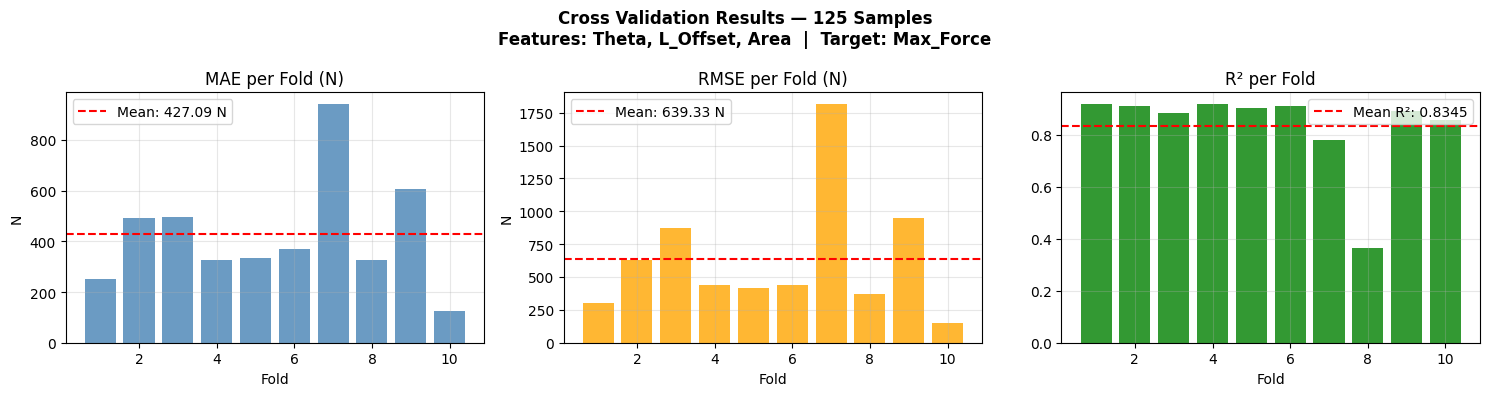

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Cross Validation Results — {n} Samples\nFeatures: Theta, L_Offset, Area  |  Target: Max_Force',
             fontweight='bold')

folds = range(1, K + 1)

axes[0].bar(folds, fold_mae_list, color='steelblue', alpha=0.8)
axes[0].axhline(np.mean(fold_mae_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_mae_list):.2f} N')
axes[0].set_title('MAE per Fold (N)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('N')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(folds, fold_rmse_list, color='orange', alpha=0.8)
axes[1].axhline(np.mean(fold_rmse_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_rmse_list):.2f} N')
axes[1].set_title('RMSE per Fold (N)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('N')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].bar(folds, fold_r2_list, color='green', alpha=0.8)
axes[2].axhline(np.mean(fold_r2_list), color='red', linestyle='--',
                label=f'Mean R²: {np.mean(fold_r2_list):.4f}')
axes[2].set_title('R² per Fold')
axes[2].set_xlabel('Fold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [113]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'x_mean':x_mean,
    'x_std':x_std,
    'y_mean':y_mean,
    'y_std':y_std,
}, 'Small_data_predictio.pt')

def predict(model,x_mean,x_std,y_mean,y_std,theta,l_offset,area,device):

    model.eval()
    with torch.no_grad():

        # Step 1 — build a tensor from the raw input values
        x_raw = torch.tensor([[theta, l_offset, area]], dtype=torch.float32)

        # Step 2 — normalise using the same statistics from training
        x_norm = (x_raw - x_mean) / x_std

        # Step 3 — move to device and run through the model
        x_norm = x_norm.to(device)
        y_norm = model(x_norm)

        # Step 4 — convert prediction back to Newtons
        y_real = (y_norm.cpu() * y_std) + y_mean

    return y_real.item()

print(f"\n{'='*50}")
print(f"  INFERENCE EXAMPLES")
print(f"{'='*50}")
print(f"{'Theta':>8} | {'L_Offset':>10} | {'Area':>10} | {'Predicted (N)':>15}")
print(f"{'-'*50}")

test_inputs = [
    (25.0, 0.5,  0.005),
    (10.0, 0.2,  0.003),
    (45.0, 1.0,  0.010),
    (5.0,  0.1,  0.002),
    (35.0, 0.75, 0.008),
]

for theta, l_offset, area in test_inputs:
    prediction = predict(model, x_mean, x_std, y_mean, y_std,
                         theta, l_offset, area, device)
    print(f"{theta:>8.1f} | {l_offset:>10.3f} | {area:>10.4f} | {prediction:>15.4f}")

print(f"{'='*50}")


  INFERENCE EXAMPLES
   Theta |   L_Offset |       Area |   Predicted (N)
--------------------------------------------------
    25.0 |      0.500 |     0.0050 |        874.3483
    10.0 |      0.200 |     0.0030 |        970.6262
    45.0 |      1.000 |     0.0100 |       1438.9253
     5.0 |      0.100 |     0.0020 |       1057.2329
    35.0 |      0.750 |     0.0080 |       1173.9348
